<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/course/chapter11/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementing Custom Evaluations ##

We can use lighteval to evaluate the finetuned model on standard benchmarks, which contain a wide range of tasks built into the library. We just need to define the tasks we want to evaluate and the parameters for the evalutation

LightEval tasks are defined using a specific format:

{suite}|{task}|{num_few_shot}|{auto_reduce}
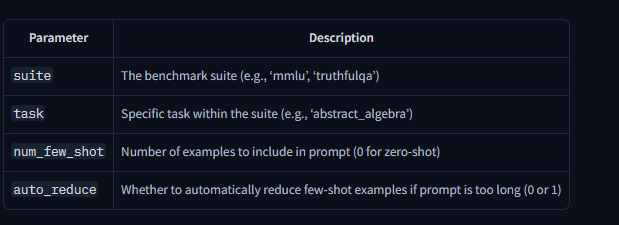

For example, "mmlu|abstract_algebra|0|0" evaluates on MMLU's abstract algebra task with zero-shot inference.

## Example Evaluation Pipeline ##

Let's set up an evaluation pipeline for our finetuned model. We will evaluate the model on set of sub tasks that relate to the domain of medicine.

Here's a complete example of evaluating on automatic benchmarks relevant to one specific domain using Lighteval with the VLLM backend:

In [ ]:
lighteval accelerate \
    "pretrained=your-model-name" \
    "mmlu|anatomy|0|0" \
    "mmlu|high_school_biology|0|0" \
    "mmlu|high_school_chemistry|0|0" \
    "mmlu|professional_medicine|0|0" \
    --max_samples 40 \
    --batch_size 1 \
    --output_path "./results" \
    --save_generations true

Results are displayed in a tabular format showing:

In [ ]:
|                  Task                  |Version|Metric|Value |   |Stderr|
|----------------------------------------|------:|------|-----:|---|-----:|
|all                                     |       |acc   |0.3333|±  |0.1169|
|leaderboard:mmlu:_average:5             |       |acc   |0.3400|±  |0.1121|
|leaderboard:mmlu:anatomy:5              |      0|acc   |0.4500|±  |0.1141|
|leaderboard:mmlu:high_school_biology:5  |      0|acc   |0.1500|±  |0.0819|

Lighteval also include a python API for more detailed evaluation tasks, which is useful for manipulating the results in a more flexible way.

## Using the Python API ##
Lighteval can be used from a custom Python script. To evaluate a model, we need to set up an EvaluationTracker, PipelineParameters, a model or model_config, and a Pipeline.

In [1]:
!pip install lighteval[vllm]

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of inspect-ai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of inspect-ai to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could t

In [2]:
from huggingface_hub import login

login()

In [1]:
import lighteval
from lighteval.logging.evaluation_tracker import EvaluationTracker
from lighteval.models.vllm.vllm_model import VLLMModelConfig
from lighteval.pipeline import ParallelismManager, Pipeline, PipelineParameters
from lighteval.utils.imports import is_package_available

if is_package_available('accelerate'):
  from datetime import timedelta
  from accelerate import Accelerator, InitProcessGroupKwargs
  accelerator = Accelerator(kwargs_handlers=[InitProcessGroupKwargs(timeout=timedelta(seconds=3000))])
else:
    accelerator = None

def main():
  evaluation_tracker = EvaluationTracker(
      output_dir="./results",
      save_details=True,
      push_to_hub=True,
      hub_results_org="pop123-ux"
  )

  pipeline_params = PipelineParameters(
      launcher_type=ParallelismManager.ACCELERATE,
      custom_tasks_directory=None, # Set to path if using custom tasks
      # Remove the parameter below once your configuration is tested
      max_samples=10,
  )

  model_config = VLLMModelConfig(
      model_name='HuggingFaceH4/zephyr-7b-beta',
      dtype='float16',
  )

  task = 'gsm8k|5'

  pipeline = Pipeline(
      tasks=task,
      pipeline_parameters=pipeline_params,
      evaluation_tracker=evaluation_tracker,
      model_config=model_config,
  )

  pipeline.evaluate()
  pipeline.save_and_push_results()
  pipeline.show_results()

if __name__ == "__main__":
  main()

INFO 07-18 15:29:16 [__init__.py:241] Automatically detected platform cuda.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'list_models': model_name. Will not be supported from version '2.0'.

Use `search` instead.
  warnings.warn(message, FutureWarning)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'list_models': model_name. Will not be supported from version '2.0'.

Use `search` instead.
  warnings.warn(message, FutureWarning)


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

AttributeError: TokenizersBackend has no attribute all_special_tokens_extended

# Key Components #

## EvaluationTracker ##
The EvaluationTracker handles logging and saving evaluation results. It can save results locally and optionally push them to the Hugging Face Hub

## PipelineParameters ##
PipelineParameters configures how the evaluation pipeline runs, including parallelism settings and task configuration.

## Model Configuration ##
Model configurations define the model to be evaluated, including the model name, data type, and other model-specific parameters. Different backends (VLLM, Transformers, etc.) have their own configuration classes

## Pipeline ##
The Pipeline orchestrates the entire evaluation process, taking the tasks, model configurations and parameters to run the evaluation

# Custom Tasks #
To use custom tasks, we se the custom_tasks_directory parameter to the path containing our custom task definitions:

In [ ]:
pipeline_params = PipelineParameters(
    custom_tasks_directory="./path/to/custom/tasks",
    # ... other params.
)

Custom example code, extracting tasks from a .csv file:

In [ ]:
from lighteval.tasks.lighteval_task import LightevalTaskConfig
from lighteval.tasks.requests import Doc
from lighteval.metrics.metrics import Metrics

def csv_prompt_fn(line: dict, task_name: str) -> Doc:
  return Doc(
      task_name=task_name,
      query=f"Question: {line['question']}\nAnswer:",
      choices=[line['answer']],
      gold_index=0, # The index of the right answer
      instruction='Answers in short and be objective.'
  )

custom_task = LightevalTaskConfig(
    name='my_csv_test',
    suite=['community'],
    metric=[Metrics.accuracy],
    hf_repo='csv',
    # The exact path to your local CSV file
    hf_data_files=[{'split': 'train', 'path': "./test.csv"}],
    hf_avail_splits=['train'], # The subsets are in train, there are no eval/test subsets of the dataset
    evaluation_splits=['train'],
    prompt_function=csv_prompt_fn,
)

# Default initialization in the lighteval system
TASKS_TABLE = [custom_task]